# 🤖 Flujo Completo de Machine Learning
### Ejemplo educativo mínimo y funcional

**Dominio:** Préstamos bancarios — predicción de monto aprobado (regresión) y aprobación (clasificación)  
**Objetivo:** Mostrar el flujo completo: datos → limpieza → pipeline → modelos → evaluación

---
| Sección | Contenido |
|---|---|
| 1 | Creación del dataset |
| 2 | Limpieza de datos |
| 3 | Calidad de datos |
| 4 | Train/Test Split |
| 5 | Preparación del pipeline |
| 6 | Modelos de regresión |
| 7 | Modelos de clasificación |
| 8 | Evaluación comparativa |

In [6]:
# ── Importaciones ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, precision_score, recall_score, f1_score,
                             classification_report)

np.random.seed(42)
print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


---
## 1. Creación del Dataset

Simulamos un dataset de **solicitudes de préstamos bancarios** con:
- Variables numéricas: edad, ingreso mensual, meses de empleo, monto solicitado
- Variables categóricas: tipo de empleo, estado civil
- **Variable objetivo regresión:** `monto_aprobado` (cuánto aprobó el banco)
- **Variable objetivo clasificación:** `aprobado` (1 = sí, 0 = no)
- Valores faltantes e inconsistencias **intencionales** para demostrar limpieza

In [7]:
# ── Dataset inventado con errores intencionales ────────────────
datos_raw = pd.DataFrame({
    'edad': [25, 34, 45, 28, 52, 31, 41, 38, None, 27,
             33, 60, 29, 47, 35, 23, 55, 43, 30, 39,
             26, 50, 36, None, 44],

    'ingreso_mensual': [2500, 4800, 7200, 3100, 9500, 3800, 6100, 5300, 4200, 2900,
                        4100, 8800, 3300, 7000, 4900, 2200, 9200, 6500, 3700, 5100,
                        2800, 8100, 4600, 3900, 999999],   # <-- outlier obvio

    'meses_empleo': [12, 36, 84, 8, 120, 24, 60, 48, None, 6,
                     30, 156, 18, 96, 42, 4, 132, 72, 20, 54,
                     10, 108, 38, 16, 66],

    'monto_solicitado': [10000, 25000, 40000, 15000, 60000, 18000, 35000, 28000, 20000, 12000,
                         22000, 55000, 16000, 45000, 27000, 8000, 58000, 38000, 17000, 30000,
                         11000, 50000, 24000, 19000, 32000],

    'tipo_empleo': ['Dependiente', 'Independiente', 'dependiente', 'DEPENDIENTE', 'Independiente',
                    'Dependiente', 'independiente', 'Dependiente', 'Independiente', 'Dependiente',
                    'Dependiente', 'Independiente', 'Dependiente', 'independiente', 'Dependiente',
                    'Dependiente', 'Independiente', 'Dependiente', 'Dependiente', 'Independiente',
                    'Dependiente', 'Independiente', 'dependiente', 'Dependiente', 'Independiente'],

    'estado_civil': ['Soltero', 'Casado', 'Casado', None, 'Casado',
                     'Soltero', 'Casado', 'Soltero', 'Casado', 'Soltero',
                     'Soltero', 'Casado', 'Soltero', 'Casado', 'Casado',
                     'Soltero', 'Casado', 'Casado', 'Soltero', 'Soltero',
                     'Soltero', 'Casado', 'Casado', 'Soltero', 'Casado'],

    # Variable objetivo regresión: monto que el banco aprueba
    'monto_aprobado': [8000, 22000, 38000, 12000, 55000, 15000, 32000, 25000, 18000, 9000,
                       20000, 50000, 13000, 42000, 24000, 6000, 54000, 35000, 14000, 27000,
                       9000, 46000, 21000, 16000, 29000],

    # Variable objetivo clasificación: 1=aprobado, 0=rechazado
    'aprobado': [1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
                 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
                 0, 1, 1, 1, 1]
})

print(f'Dataset creado: {datos_raw.shape[0]} filas × {datos_raw.shape[1]} columnas')
datos_raw.head(8)

Dataset creado: 25 filas × 8 columnas


,edad,ingreso_mensual,meses_empleo,monto_solicitado,tipo_empleo,estado_civil,monto_aprobado,aprobado
0,25.0,2500,12.0,10000,Dependiente,Soltero,8000,1
1,34.0,4800,36.0,25000,Independiente,Casado,22000,1
2,45.0,7200,84.0,40000,dependiente,Casado,38000,1
3,28.0,3100,8.0,15000,DEPENDIENTE,NaN,12000,1
4,52.0,9500,120.0,60000,Independiente,Casado,55000,1
5,31.0,3800,24.0,18000,Dependiente,Soltero,15000,1
6,41.0,6100,60.0,35000,independiente,Casado,32000,1
7,38.0,5300,48.0,28000,Dependiente,Soltero,25000,1


---
## 2. Limpieza de Datos

Tratamos los problemas encontrados en el dataset:
1. **Corrección de tipos** — asegurar que cada columna tenga el tipo correcto
2. **Estandarización de categorías** — unificar variantes de texto (mayúsculas, minúsculas)
3. **Detección de outliers** — identificar valores numéricamente imposibles o extremos
4. **Valores faltantes** — identificar dónde están los nulos (el tratamiento se hace en el pipeline)

In [8]:
# ── Paso 1: Copiar para no modificar el raw ────────────────────
datos = datos_raw.copy()

# ── Paso 2: Corrección de tipos ────────────────────────────────
# edad y meses_empleo deben ser numéricos (float por los NaN)
datos['edad']         = pd.to_numeric(datos['edad'],         errors='coerce')
datos['meses_empleo'] = pd.to_numeric(datos['meses_empleo'], errors='coerce')

print('✅ Tipos corregidos:')
print(datos.dtypes)
print()

✅ Tipos corregidos:
edad                float64
ingreso_mensual       int64
meses_empleo        float64
monto_solicitado      int64
tipo_empleo             str
estado_civil            str
monto_aprobado        int64
aprobado              int64
dtype: object



In [9]:
# ── Paso 3: Estandarización de categorías ─────────────────────
# Problema: 'dependiente', 'DEPENDIENTE', 'Dependiente' → son lo mismo
print('Antes — valores únicos de tipo_empleo:', datos['tipo_empleo'].unique())

datos['tipo_empleo']  = datos['tipo_empleo'].str.strip().str.capitalize()
datos['estado_civil'] = datos['estado_civil'].str.strip().str.capitalize()

print('Después:', datos['tipo_empleo'].unique())

Antes — valores únicos de tipo_empleo: <StringArray>
['Dependiente', 'Independiente', 'dependiente', 'DEPENDIENTE',
 'independiente']
Length: 5, dtype: str
Después: <StringArray>
['Dependiente', 'Independiente']
Length: 2, dtype: str


In [10]:
# ── Paso 4: Detección y corrección de outliers ─────────────────
# Regla simple: ingreso > percentil 99 se considera error de captura → reemplazar con NaN
limite_ingreso = datos['ingreso_mensual'].quantile(0.99)
outliers = datos[datos['ingreso_mensual'] > limite_ingreso]

print(f'Outliers de ingreso detectados (> ${limite_ingreso:,.0f}):')
print(outliers[['edad', 'ingreso_mensual']].to_string())

datos.loc[datos['ingreso_mensual'] > limite_ingreso, 'ingreso_mensual'] = np.nan
print('\n✅ Outlier reemplazado con NaN para tratar en el pipeline')

Outliers de ingreso detectados (> $762,279):
    edad  ingreso_mensual
24  44.0           999999

✅ Outlier reemplazado con NaN para tratar en el pipeline


In [11]:
# ── Paso 5: Resumen de valores faltantes ──────────────────────
nulos = datos.isnull().sum()
nulos = nulos[nulos > 0]
print('Valores faltantes por columna:')
print(nulos.to_frame('nulos').assign(pct=lambda d: (d['nulos']/len(datos)*100).round(1)))

Valores faltantes por columna:
                 nulos  pct
edad                 2  8.0
ingreso_mensual      1  4.0
meses_empleo         1  4.0
estado_civil         1  4.0


---
## 3. Calidad de Datos

Evaluamos 4 dimensiones esenciales de calidad:

In [12]:
print('=' * 55)
print('REPORTE DE CALIDAD DE DATOS')
print('=' * 55)

# 1. COMPLETITUD — ¿hay valores faltantes?
completitud = (1 - datos.isnull().mean()).mean() * 100
print(f'\n📋 COMPLETITUD: {completitud:.1f}%')
print('   (% de celdas con datos presentes)')
cols_con_nulos = datos.isnull().sum()
print(cols_con_nulos[cols_con_nulos > 0].to_string())

# 2. UNICIDAD — ¿hay registros duplicados?
n_dup = datos.duplicated().sum()
print(f'\n🔁 UNICIDAD: {n_dup} filas duplicadas encontradas')
if n_dup > 0:
    datos = datos.drop_duplicates()
    print('   → Duplicados eliminados')

# 3. CONSISTENCIA — ¿hay contradicciones lógicas?
# Regla: monto_aprobado no puede ser mayor que monto_solicitado
inconsistentes = datos[datos['monto_aprobado'] > datos['monto_solicitado']]
print(f'\n⚠️  CONSISTENCIA: {len(inconsistentes)} registros donde aprobado > solicitado')

# 4. VALIDEZ — ¿hay valores fuera de rango?
edades_invalidas  = datos[(datos['edad'] < 18) | (datos['edad'] > 90)].shape[0]
ingresos_invalidos = datos[datos['ingreso_mensual'] < 0].shape[0]
print(f'\n✔️  VALIDEZ:')
print(f'   Edades fuera de rango [18-90]:   {edades_invalidas}')
print(f'   Ingresos negativos:              {ingresos_invalidos}')

print('\n✅ Calidad evaluada. Dataset listo para modelado.')

REPORTE DE CALIDAD DE DATOS

📋 COMPLETITUD: 97.5%
   (% de celdas con datos presentes)
edad               2
ingreso_mensual    1
meses_empleo       1
estado_civil       1

🔁 UNICIDAD: 0 filas duplicadas encontradas

⚠️  CONSISTENCIA: 0 registros donde aprobado > solicitado

✔️  VALIDEZ:
   Edades fuera de rango [18-90]:   0
   Ingresos negativos:              0

✅ Calidad evaluada. Dataset listo para modelado.


---
## 4. Train / Test Split

Separamos:
- **Variables predictoras (X):** todo excepto las variables objetivo
- **Variable objetivo regresión (y_reg):** `monto_aprobado`
- **Variable objetivo clasificación (y_clf):** `aprobado`

División: **75% entrenamiento / 25% test** con semilla fija para reproducibilidad.

In [13]:
# ── Definir X e y ─────────────────────────────────────────────
TARGET_REG = 'monto_aprobado'
TARGET_CLF = 'aprobado'
FEATURES   = ['edad', 'ingreso_mensual', 'meses_empleo', 'monto_solicitado',
               'tipo_empleo', 'estado_civil']

X     = datos[FEATURES]
y_reg = datos[TARGET_REG]
y_clf = datos[TARGET_CLF]

# ── Split ─────────────────────────────────────────────────────
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.25, random_state=42)

_, _, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.25, random_state=42)   # mismo random_state → mismo split

print(f'X completo:     {X.shape}')
print(f'X_train:        {X_train.shape}   ({len(X_train)/len(X)*100:.0f}%)')
print(f'X_test:         {X_test.shape}    ({len(X_test)/len(X)*100:.0f}%)')
print(f'\nVariables predictoras: {FEATURES}')
print(f'Target regresión:      {TARGET_REG}')
print(f'Target clasificación:  {TARGET_CLF}')

X completo:     (25, 6)
X_train:        (18, 6)   (72%)
X_test:         (7, 6)    (28%)

Variables predictoras: ['edad', 'ingreso_mensual', 'meses_empleo', 'monto_solicitado', 'tipo_empleo', 'estado_civil']
Target regresión:      monto_aprobado
Target clasificación:  aprobado


---
## 5. Preparación del Pipeline

### Estrategia de transformaciones

| Variable | Tipo | Transformaciones |
|---|---|---|
| edad, ingreso_mensual, meses_empleo, monto_solicitado | Numérica | Imputación (mediana) → Escalamiento (Z-score) |
| tipo_empleo, estado_civil | Categórica | Imputación (más frecuente) → One-Hot Encoding |

> ⚠️ Para árboles de decisión **no se aplica escalamiento** (son invariantes a la magnitud).

In [14]:
# ── Separar columnas por tipo ──────────────────────────────────
cols_num = ['edad', 'ingreso_mensual', 'meses_empleo', 'monto_solicitado']
cols_cat = ['tipo_empleo', 'estado_civil']

# ── Pipeline numérico ──────────────────────────────────────────
# Imputar con mediana (robusta a outliers) + estandarizar con Z-score
pipe_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# ── Pipeline categórico ────────────────────────────────────────
# Imputar con el valor más frecuente + One-Hot Encoding
pipe_cat = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ── ColumnTransformer: combina ambos pipelines ─────────────────
preprocesador = ColumnTransformer([
    ('num', pipe_num, cols_num),
    ('cat', pipe_cat, cols_cat)
])

# ── Pipeline numérico SIN scaler (para árboles) ────────────────
pipe_num_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])
preprocesador_tree = ColumnTransformer([
    ('num', pipe_num_tree, cols_num),
    ('cat', pipe_cat,      cols_cat)
])

print('✅ Preprocesadores definidos:')
print('   - preprocesador       → para modelos lineales (con escalamiento)')
print('   - preprocesador_tree  → para árboles (sin escalamiento)')

✅ Preprocesadores definidos:
   - preprocesador       → para modelos lineales (con escalamiento)
   - preprocesador_tree  → para árboles (sin escalamiento)


---
## 6. Modelos de Regresión

Construimos tres pipelines de regresión para predecir `monto_aprobado`:

1. **Regresión Lineal** — modelo base, relación lineal directa
2. **Regresión Polinomial (grado 2)** — captura relaciones no lineales
3. **Ridge (Regresión Regularizada L2)** — penaliza coeficientes grandes para reducir overfitting

In [15]:
# ── 6.1 Regresión Lineal ───────────────────────────────────────
pipe_lineal = Pipeline([
    ('prep',  preprocesador),
    ('model', LinearRegression())
])

# ── 6.2 Regresión Polinomial (grado 2) ────────────────────────
# PolynomialFeatures eleva y cruza las features DESPUÉS del preprocesamiento
pipe_poli = Pipeline([
    ('prep',  preprocesador),
    ('poly',  PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])

# ── 6.3 Regresión Ridge (Regularización L2) ────────────────────
# alpha controla la fuerza de la regularización (más alto → más penalización)
pipe_ridge = Pipeline([
    ('prep',  preprocesador),
    ('model', Ridge(alpha=1.0))
])

# ── Entrenar los tres modelos ──────────────────────────────────
pipe_lineal.fit(X_train, y_reg_train)
pipe_poli.fit(X_train,   y_reg_train)
pipe_ridge.fit(X_train,  y_reg_train)

print('✅ Los 3 modelos de regresión entrenados correctamente')

✅ Los 3 modelos de regresión entrenados correctamente


---
## 7. Modelos de Clasificación

Construimos dos pipelines de clasificación para predecir si el préstamo será `aprobado`:

1. **Regresión Logística** — usa la función sigmoide para estimar probabilidades de clase
2. **Árbol de Decisión** — realiza particiones recursivas del espacio; no requiere escalamiento

In [16]:
# ── 7.1 Regresión Logística ────────────────────────────────────
# max_iter alto para asegurar convergencia con datos pequeños
pipe_logistica = Pipeline([
    ('prep',  preprocesador),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# ── 7.2 Árbol de Decisión ─────────────────────────────────────
# max_depth=3 para evitar overfitting en datasets pequeños
# Usamos preprocesador_tree (sin escalamiento) — los árboles son invariantes a la escala
pipe_arbol = Pipeline([
    ('prep',  preprocesador_tree),
    ('model', DecisionTreeClassifier(max_depth=3, random_state=42))
])

# ── Entrenar los dos clasificadores ───────────────────────────
pipe_logistica.fit(X_train, y_clf_train)
pipe_arbol.fit(X_train,     y_clf_train)

print('✅ Los 2 modelos de clasificación entrenados correctamente')

✅ Los 2 modelos de clasificación entrenados correctamente


---
## 8. Evaluación de Modelos

### 8.1 Regresión — métricas sobre el conjunto de test

| Métrica | Qué mide |
|---|---|
| **RMSE** | Error cuadrático medio. Penaliza errores grandes. Mismas unidades que y. |
| **MAE** | Error absoluto medio. Todos los errores pesan igual. |
| **R²** | Proporción de varianza explicada. 1.0 = perfecto. |

In [17]:
def eval_regresion(nombre, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    return {'Modelo': nombre, 'RMSE': f'${rmse:,.0f}', 'MAE': f'${mae:,.0f}', 'R²': f'{r2:.3f}'}

resultados_reg = pd.DataFrame([
    eval_regresion('Regresión Lineal',     pipe_lineal,  X_test, y_reg_test),
    eval_regresion('Regresión Polinomial', pipe_poli,    X_test, y_reg_test),
    eval_regresion('Ridge (L2)',           pipe_ridge,   X_test, y_reg_test),
])

print('📊 RESULTADOS — REGRESIÓN (sobre test set)\n')
print(resultados_reg.to_string(index=False))
print('\n💡 Mejor RMSE/MAE = menor error  |  Mejor R² = más cercano a 1.0')

📊 RESULTADOS — REGRESIÓN (sobre test set)

              Modelo   RMSE    MAE    R²
    Regresión Lineal $1,303   $773 0.995
Regresión Polinomial $5,363 $3,746 0.915
          Ridge (L2) $2,584 $1,655 0.980

💡 Mejor RMSE/MAE = menor error  |  Mejor R² = más cercano a 1.0


### 8.2 Clasificación — métricas sobre el conjunto de test

| Métrica | Qué mide |
|---|---|
| **Accuracy** | % de predicciones correctas totales |
| **Precision** | De los que predije positivos, ¿cuántos lo eran? (costo FP) |
| **Recall** | De los positivos reales, ¿cuántos detecté? (costo FN) |
| **F1-Score** | Media armónica de Precision y Recall. Equilibrio entre ambos. |

In [18]:
def eval_clasificacion(nombre, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    return {
        'Modelo':     nombre,
        'Accuracy':   f'{accuracy_score(y_test,  y_pred):.2f}',
        'Precision':  f'{precision_score(y_test, y_pred, zero_division=0):.2f}',
        'Recall':     f'{recall_score(y_test,    y_pred, zero_division=0):.2f}',
        'F1-Score':   f'{f1_score(y_test,        y_pred, zero_division=0):.2f}',
    }

resultados_clf = pd.DataFrame([
    eval_clasificacion('Regresión Logística', pipe_logistica, X_test, y_clf_test),
    eval_clasificacion('Árbol de Decisión',   pipe_arbol,     X_test, y_clf_test),
])

print('📊 RESULTADOS — CLASIFICACIÓN (sobre test set)\n')
print(resultados_clf.to_string(index=False))
print('\n💡 Mejor = valores más cercanos a 1.0')

📊 RESULTADOS — CLASIFICACIÓN (sobre test set)

             Modelo Accuracy Precision Recall F1-Score
Regresión Logística     0.71      0.71   1.00     0.83
  Árbol de Decisión     0.71      0.80   0.80     0.80

💡 Mejor = valores más cercanos a 1.0


In [19]:
# ── Reporte detallado de clasificación ────────────────────────
print('── Regresión Logística ──────────────────────────────')
print(classification_report(y_clf_test, pipe_logistica.predict(X_test),
                             target_names=['Rechazado', 'Aprobado']))

print('── Árbol de Decisión ────────────────────────────────')
print(classification_report(y_clf_test, pipe_arbol.predict(X_test),
                             target_names=['Rechazado', 'Aprobado']))

── Regresión Logística ──────────────────────────────
              precision    recall  f1-score   support

   Rechazado       0.00      0.00      0.00         2
    Aprobado       0.71      1.00      0.83         5

    accuracy                           0.71         7
   macro avg       0.36      0.50      0.42         7
weighted avg       0.51      0.71      0.60         7

── Árbol de Decisión ────────────────────────────────
              precision    recall  f1-score   support

   Rechazado       0.50      0.50      0.50         2
    Aprobado       0.80      0.80      0.80         5

    accuracy                           0.71         7
   macro avg       0.65      0.65      0.65         7
weighted avg       0.71      0.71      0.71         7



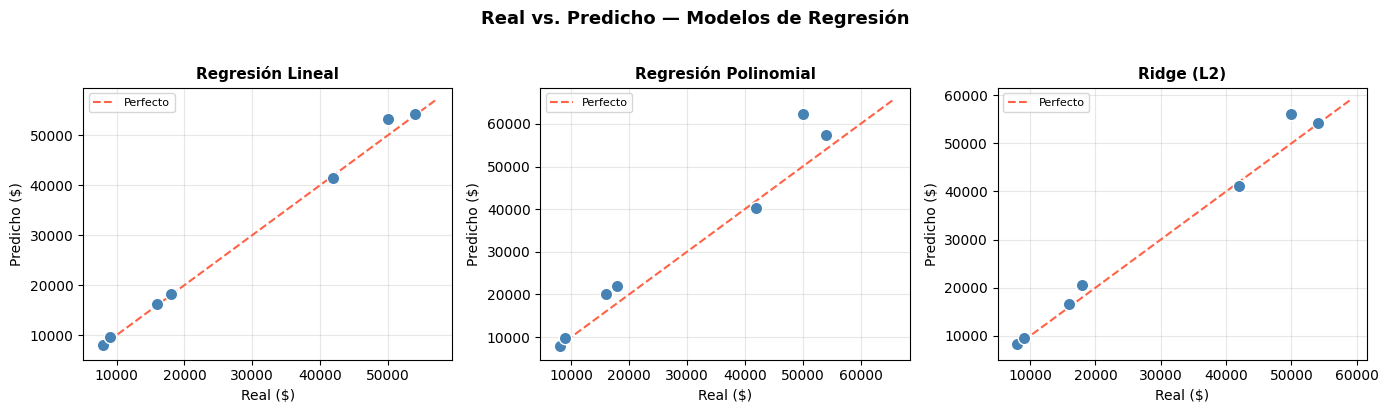


💡 Cuanto más cerca de la línea roja, mejor la predicción.


In [20]:
# ── Visualización: predicciones regresión vs. real ────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

modelos_reg = [
    ('Regresión Lineal',     pipe_lineal),
    ('Regresión Polinomial', pipe_poli),
    ('Ridge (L2)',           pipe_ridge),
]

for ax, (nombre, pipe) in zip(axes, modelos_reg):
    y_pred = pipe.predict(X_test)
    ax.scatter(y_reg_test, y_pred, color='steelblue', edgecolors='white', s=80, zorder=3)
    lims = [min(y_reg_test.min(), y_pred.min()) * 0.95,
            max(y_reg_test.max(), y_pred.max()) * 1.05]
    ax.plot(lims, lims, '--', color='tomato', linewidth=1.5, label='Perfecto')
    ax.set_title(nombre, fontsize=11, fontweight='bold')
    ax.set_xlabel('Real ($)')
    ax.set_ylabel('Predicho ($)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Real vs. Predicho — Modelos de Regresión', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('\n💡 Cuanto más cerca de la línea roja, mejor la predicción.')

---
## ✅ Resumen del Flujo Completo

```
Dataset crudo
    ↓
[Limpieza]  Tipos · Categorías · Outliers
    ↓
[Calidad]   Completitud · Unicidad · Consistencia · Validez
    ↓
[Split]     75% Train / 25% Test  (random_state=42)
    ↓
[Pipeline]  Numérico: Imputación(mediana) → Z-score
            Categórico: Imputación(moda)  → One-Hot Encoding
    ↓
[Regresión]       Lineal | Polinomial | Ridge
[Clasificación]   Logística | Árbol de Decisión
    ↓
[Evaluación]
  Regresión:      RMSE · MAE · R²
  Clasificación:  Accuracy · Precision · Recall · F1
```

### 🔑 Decisiones de diseño clave

| Decisión | Razón |
|---|---|
| Imputar con **mediana** (numérico) | Robusta a outliers |
| **One-Hot Encoding** (categórico) | Modelos lineales no admiten orden artificial |
| **Escalamiento solo en modelos lineales** | Los árboles son invariantes a la magnitud |
| **Ridge en lugar de Lineal puro** | Reduce overfitting penalizando coeficientes grandes |
| **max_depth=3** en árbol | Controla sobreajuste en datasets pequeños |